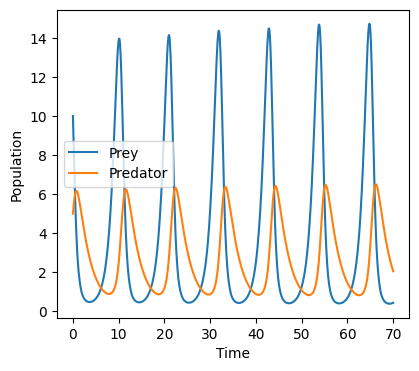

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

params = (1.1, 0.4, 0.4, 0.1)
initial_pop = [10, 5]
t_span = (0, 70)
t_eval = np.linspace(0, 70, 1000)

sol = solve_ivp(
    lotka_volterra,
    t_span,
    initial_pop,
    args=params,
    t_eval=t_eval
)

plt.figure(figsize=(10, 4))

# Time Series Plot
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], label='Prey')
plt.plot(sol.t, sol.y[1], label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()

plt.show()

Discovered Equations:
(x)' =  0.030 1 +  1.095 x + -0.014 y + -0.398 x y
(y)' = -0.398 y +  0.100 x y


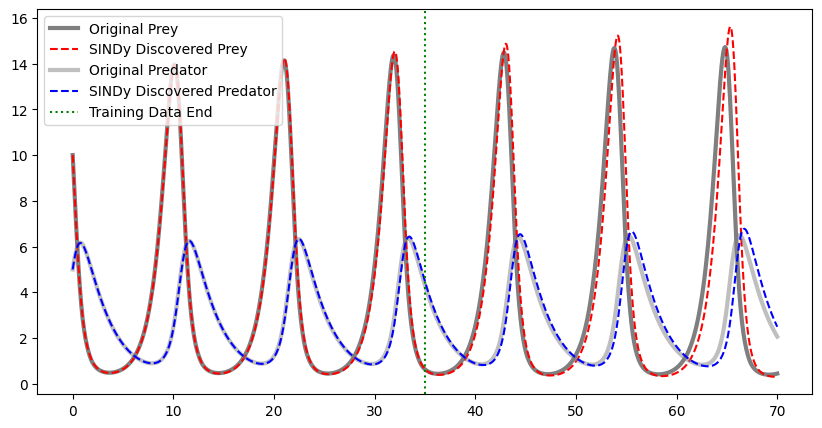

In [6]:
import pysindy as ps
import numpy as np
import matplotlib.pyplot as plt

x = sol.y[0]
y = sol.y[1]
t = sol.t

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)

optimizer = ps.STLSQ(threshold=0.01)
model = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=feature_library,
    optimizer=optimizer,
)

X = np.stack((x, y), axis=-1)
n = len(X)
cut = int(0.5 * n)

X_train = X[:cut]
t_train = t[:cut]

model.fit(X_train, t=t_train, feature_names=["x", "y"])

print("Discovered Equations:")
model.print()

x_sim = model.simulate(initial_pop, t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, sol.y[0], 'k', label='Original Prey', alpha=0.5, linewidth=3)
plt.plot(t_eval, x_sim[:, 0], 'r--', label='SINDy Discovered Prey')
plt.plot(t_eval, sol.y[1], 'gray', label='Original Predator', alpha=0.5, linewidth=3)
plt.plot(t_eval, x_sim[:, 1], 'b--', label='SINDy Discovered Predator')

plt.axvline(x=t[cut], color='green', linestyle=':', label='Training Data End')

plt.legend()
plt.show()